In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [10]:
df = pd.read_csv("datos/datos.csv")

In [11]:
df.head()
df.describe()

,appid,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,copiessold,revenue,firstreleasedate,reviewscore
count,2.323000e+04,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,2.323000e+04,2.323000e+04,2.323000e+04,23230.000000
mean,5.916447e+05,0.294791,38.654283,357.344727,82.258674,107.152217,112.587000,5.886544,6.482484e+04,2.605762e+05,1.481585e+12,70.916746
std,2.486956e+05,2.185441,310.533420,2653.099238,729.596943,1714.138494,2066.700829,6.258438,5.067301e+05,1.087396e+06,6.529230e+10,20.940744
min,2.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,9.229428e+11,0.000000
25%,3.978025e+05,0.000000,0.000000,6.000000,2.000000,0.000000,0.000000,1.690000,5.400000e+02,5.640000e+02,1.455512e+12,59.000000
50%,5.908300e+05,0.000000,8.000000,24.000000,8.000000,0.000000,0.000000,3.990000,3.213000e+03,5.133000e+03,1.499314e+12,75.000000
75%,7.908475e+05,0.000000,23.000000,118.000000,37.000000,0.000000,0.000000,7.190000,1.898500e+04,4.965075e+04,1.527134e+12,87.000000
max,1.069460e+06,18.000000,9821.000000,292574.000000,91664.000000,190625.000000,190625.000000,154.990000,5.355018e+07,1.229418e+07,1.682482e+12,100.000000


In [54]:
df.isnull().sum()

appid                   0
nombre                  0
release_date            0
english                 0
developer               1
publisher              12
publisherclass          0
platforms               0
required_age            0
categories              0
genres                  0
steamspy_tags           0
achievements            0
positive_ratings        0
negative_ratings        0
average_playtime        0
median_playtime         0
owners                  0
price                   0
copiessold              0
revenue                 0
unreleased              0
earlyaccess             0
firstreleasedate        0
reviewscore             0
platforms_lista         0
genres_lista            0
categories_lista        0
steamspy_tags_lista     0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23230 entries, 0 to 23229
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             23230 non-null  int64  
 1   nombre            23230 non-null  object 
 2   release_date      23230 non-null  object 
 3   english           23230 non-null  object 
 4   developer         23229 non-null  object 
 5   publisher         23218 non-null  object 
 6   publisherclass    23230 non-null  object 
 7   platforms         23230 non-null  object 
 8   required_age      23230 non-null  int64  
 9   categories        23230 non-null  object 
 10  genres            23230 non-null  object 
 11  steamspy_tags     23230 non-null  object 
 12  achievements      23230 non-null  int64  
 13  positive_ratings  23230 non-null  int64  
 14  negative_ratings  23230 non-null  int64  
 15  average_playtime  23230 non-null  int64  
 16  median_playtime   23230 non-null  int64 

In [14]:
print(f"Cantidad de filas antes del drop: {len(df)}")
df = df.drop_duplicates()
print(f"Cantidad de filas después del drop: {len(df)}")

Cantidad de filas antes del drop: 23230
Cantidad de filas después del drop: 23230


In [15]:
X = df.drop(columns=["copiessold"]).copy()
y = df["copiessold"].copy()

print("Dimensiones (filas, columnas):", df.shape)
df.head()


Dimensiones (filas, columnas): (23230, 25)


,appid,nombre,release_date,english,developer,publisher,publisherclass,platforms,required_age,categories,...,average_playtime,median_playtime,owners,price,copiessold,revenue,unreleased,earlyaccess,firstreleasedate,reviewscore
0,20,Team Fortress Classic,1999-04-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,...,277,62,5000000-10000000,3.99,385769,862278,False,False,922942800000,87
1,30,Day of Defeat,2003-05-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,...,187,34,5000000-10000000,3.99,234765,500723,False,False,1051761600000,90
2,40,Deathmatch Classic,2001-06-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,...,258,184,5000000-10000000,3.99,146340,312387,False,False,991368000000,83
3,50,Half-Life: Opposing Force,1999-11-01,t,Gearbox Software,Valve,AAA,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,...,624,415,5000000-10000000,3.99,815610,1641208,False,False,941432400000,95
4,60,Ricochet,2000-11-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,...,175,10,5000000-10000000,3.99,289530,619066,False,False,973054800000,83


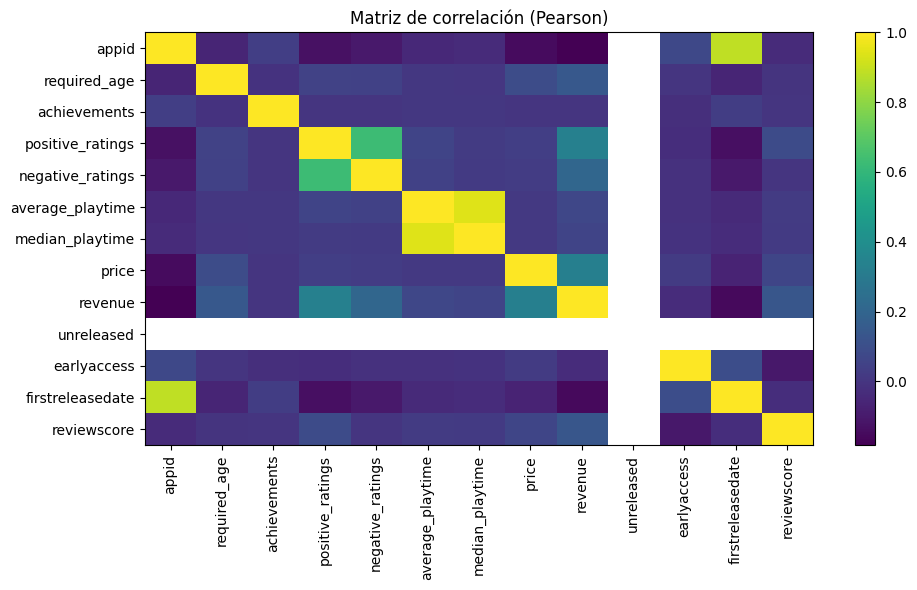

In [16]:
corr = X.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()


In [40]:
columnas_cuantitativas = ["price", "revenue", "required_age", "achievements", "positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "price", "firstreleasedate", "reviewscore"]
columnas_lista = ["platforms", "genres", "categories", "steamspy_tags"]

df_cuantitativo = X[columnas_cuantitativas].copy()
df_lista = X[columnas_lista].copy()
df_cualitativo = X.drop(columns=list(df_cuantitativo.columns) + list(df_lista.columns)).copy()

In [41]:
from sklearn.preprocessing import MultiLabelBinarizer

df_binarizado_total = pd.DataFrame()

for columna in columnas_lista:
    listas = df_lista[columna].fillna('').str.split(';')
    mlb = MultiLabelBinarizer()
    datos_binarizados = mlb.fit_transform(listas)
    df_temp = pd.DataFrame(datos_binarizados,
                           columns=mlb.classes_,
                           index=df_lista.index).add_prefix(f'{columna}_')
    df_binarizado_total = pd.concat([df_binarizado_total, df_temp], axis=1)

generos_binarizados = mlb.fit_transform(df_lista)

# `mlb.classes_` te muestra los géneros que encontró en orden
print("Vista previa del DataFrame binarizado final:")
print(df_binarizado_total.head())

Vista previa del DataFrame binarizado final:
   platforms_linux  platforms_mac  platforms_windows  genres_Accounting  \
0                1              1                  1                  0   
1                1              1                  1                  0   
2                1              1                  1                  0   
3                1              1                  1                  0   
4                1              1                  1                  0   

   genres_Action  genres_Adventure  genres_Animation & Modeling  \
0              1                 0                            0   
1              1                 0                            0   
2              1                 0                            0   
3              1                 0                            0   
4              1                 0                            0   

   genres_Audio Production  genres_Casual  genres_Design & Illustration  ...  \
0                    

In [ ]:
encoder = OneHotEncoder(
    min_frequency=100,
    handle_unknown='ignore',
    dtype=np.float32,
    drop="first"
)

result = encoder.fit_transform(df_cualitativo).toarray()

column_names = encoder.get_feature_names_out(df_cualitativo.columns)

data_scaled = pd.DataFrame(result, columns=column_names, index=df_cualitativo.index)
df_encoded = pd.concat([data_scaled, df_cuantitativo, df_binarizado_total], axis=1)
df_encoded.head()

,english_t,publisher_Strategy First,publisher_infrequent_sklearn,publisherclass_AAA,publisherclass_Hobbyist,publisherclass_Indie,owners_100000-200000,owners_1000000-2000000,owners_20000-50000,owners_200000-500000,...,steamspy_tags_Wargame,steamspy_tags_Warhammer 40K,steamspy_tags_Werewolves,steamspy_tags_Western,steamspy_tags_Word Game,steamspy_tags_World War I,steamspy_tags_World War II,steamspy_tags_Wrestling,steamspy_tags_Zombies,steamspy_tags_e-sports
0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
scaler = MinMaxScaler()
#Falta OneHotEncoder y lo que hice arriba con el multilabel (mañana lo termino antes de la reu)
X_scaled = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns, index=df_encoded.index)

# Verificamos: media ~0, std ~1
display(X_scaled.describe().loc[["mean", "std"]])

,english_t,publisher_Strategy First,publisher_infrequent_sklearn,publisherclass_AAA,publisherclass_Hobbyist,publisherclass_Indie,owners_100000-200000,owners_1000000-2000000,owners_20000-50000,owners_200000-500000,...,steamspy_tags_Wargame,steamspy_tags_Warhammer 40K,steamspy_tags_Werewolves,steamspy_tags_Western,steamspy_tags_Word Game,steamspy_tags_World War I,steamspy_tags_World War II,steamspy_tags_Wrestling,steamspy_tags_Zombies,steamspy_tags_e-sports
mean,0.981274,0.005725,0.985235,0.018597,0.366896,0.562591,0.049290,0.005725,0.115239,0.045286,...,0.000646,0.000258,0.000129,0.000947,0.000344,0.000904,0.005037,0.000258,0.005381,0.000086
std,0.135558,0.075451,0.120615,0.135098,0.481968,0.496078,0.216477,0.075451,0.319317,0.207936,...,0.025403,0.016070,0.011364,0.030760,0.018555,0.030054,0.070792,0.016070,0.073159,0.009279


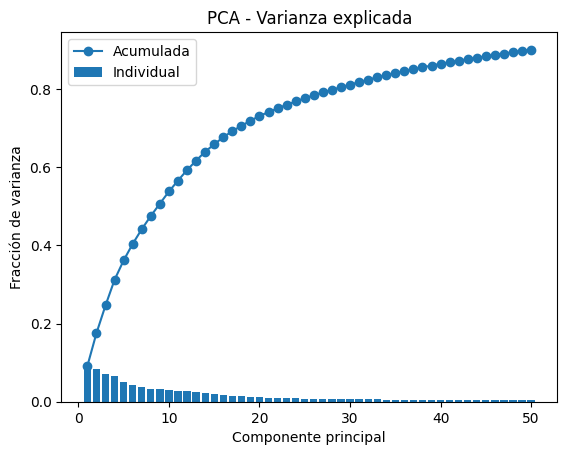

ValueError: Image size of 565x245271 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [47]:
pca = PCA(n_components=50)
pca.fit(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp = np.cumsum(exp_var)
k = len(exp_var)

# Varianza explicada
fig, ax = plt.subplots()
ax.bar(range(1, k+1), exp_var, label="Individual")
ax.plot(range(1, k+1), cum_exp, marker="o", label="Acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Fracción de varianza")
ax.set_title("PCA - Varianza explicada")
ax.legend()
plt.show()

# Proyección 2D
Z = pca.transform(X_scaled)
pc1, pc2 = Z[:,0], Z[:,1]

fig, ax = plt.subplots()
for c in np.unique(y):
    sel = y.values == c
    ax.scatter(pc1[sel], pc2[sel], s=35, alpha=0.8, label=f"Clase {c}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - Proyección 2D (PC1 vs PC2)")
ax.legend()
plt.show()

In [49]:
pca = PCA(n_components=min(50, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum()
print(f"Dimensión tras PCA: {X_pca.shape}, varianza explicada acumulada: {explained:.3f}")

Dimensión tras PCA: (23230, 50), varianza explicada acumulada: 0.901


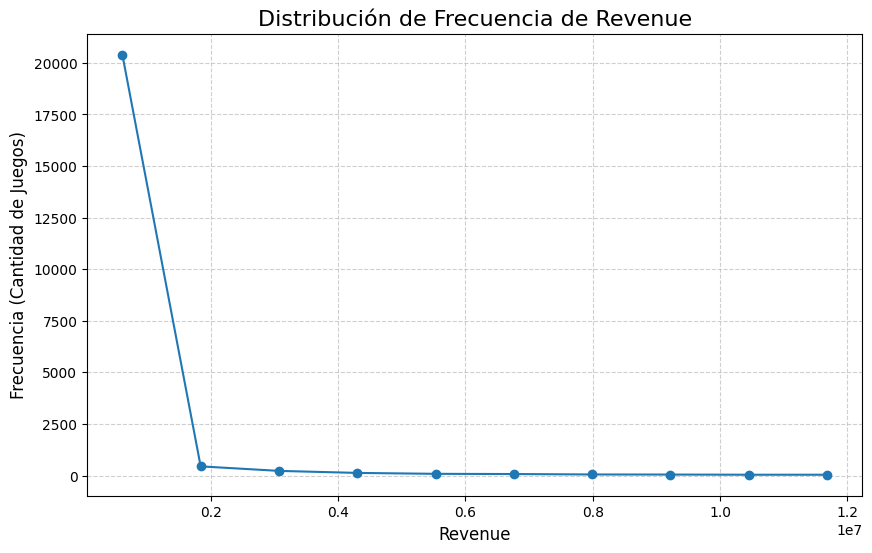

In [74]:
condition = (df_encoded["revenue"] == 0) & (df_encoded["price"] == 0)
indices_to_drop = df_encoded[condition].index
df_revenue = df.drop(indices_to_drop)

counts, bin_edges = np.histogram(df_revenue['revenue'], bins=10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.figure(figsize=(10, 6))

plt.plot(bin_centers, counts, marker='o', linestyle='-')

plt.title('Distribución de Frecuencia de Revenue', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

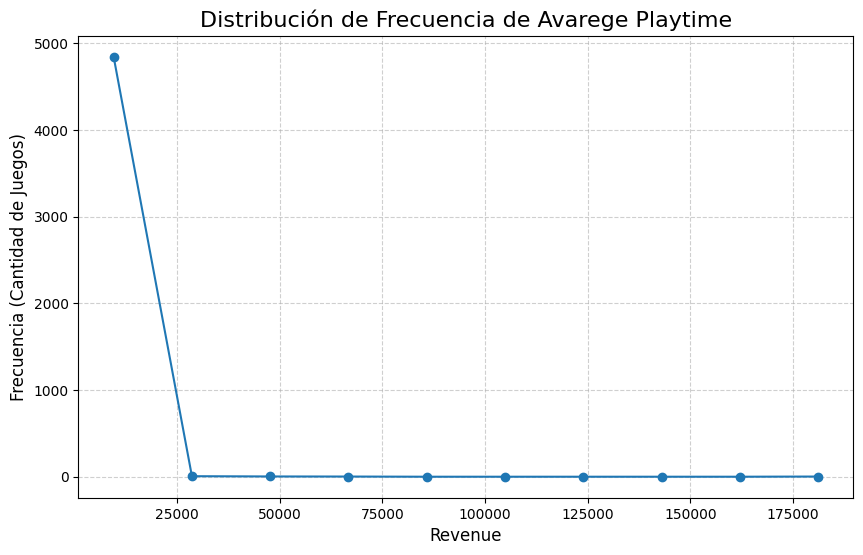

In [71]:
condition = (df_encoded["median_playtime"] == 0)
indices_to_drop = df_encoded[condition].index
df_avg = df_encoded.drop(indices_to_drop)

counts, bin_edges = np.histogram(df_avg['median_playtime'], bins=10) 
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de línea
plt.plot(bin_centers, counts, marker='o', linestyle='-')

plt.title('Distribución de Frecuencia de Avarege Playtime', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

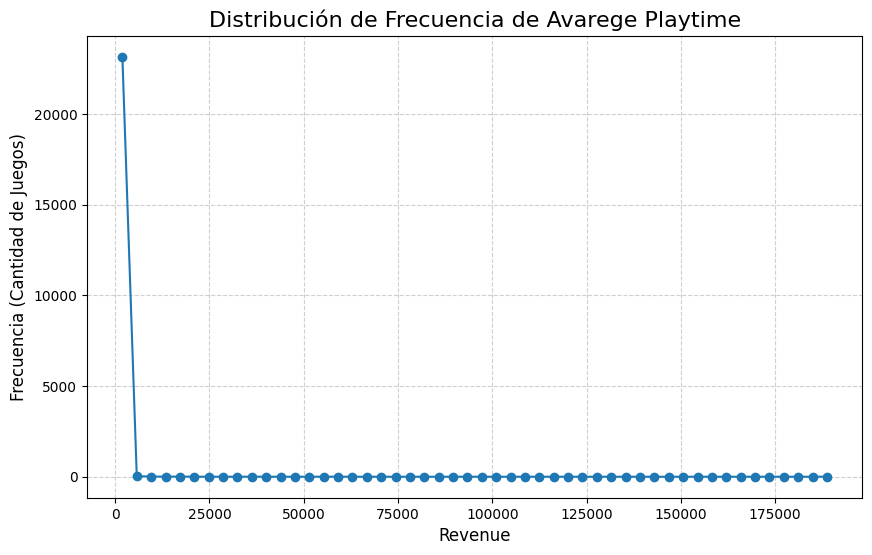

In [68]:
condition = (df["average_playtime"] == 0)
indices_to_drop = df[condition].index
df_avg = df.drop(indices_to_drop)

counts, bin_edges = np.histogram(df_encoded['average_playtime'], bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de línea
plt.plot(bin_centers, counts, marker='o', linestyle='-')

plt.title('Distribución de Frecuencia de Avarege Playtime', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [91]:
print(df_encoded.columns)

Index(['english_t', 'publisher_Strategy First', 'publisher_infrequent_sklearn',
       'publisherclass_AAA', 'publisherclass_Hobbyist', 'publisherclass_Indie',
       'owners_100000-200000', 'owners_1000000-2000000', 'owners_20000-50000',
       'owners_200000-500000',
       ...
       'steamspy_tags_Wargame', 'steamspy_tags_Warhammer 40K',
       'steamspy_tags_Werewolves', 'steamspy_tags_Western',
       'steamspy_tags_Word Game', 'steamspy_tags_World War I',
       'steamspy_tags_World War II', 'steamspy_tags_Wrestling',
       'steamspy_tags_Zombies', 'steamspy_tags_e-sports'],
      dtype='object', length=407)


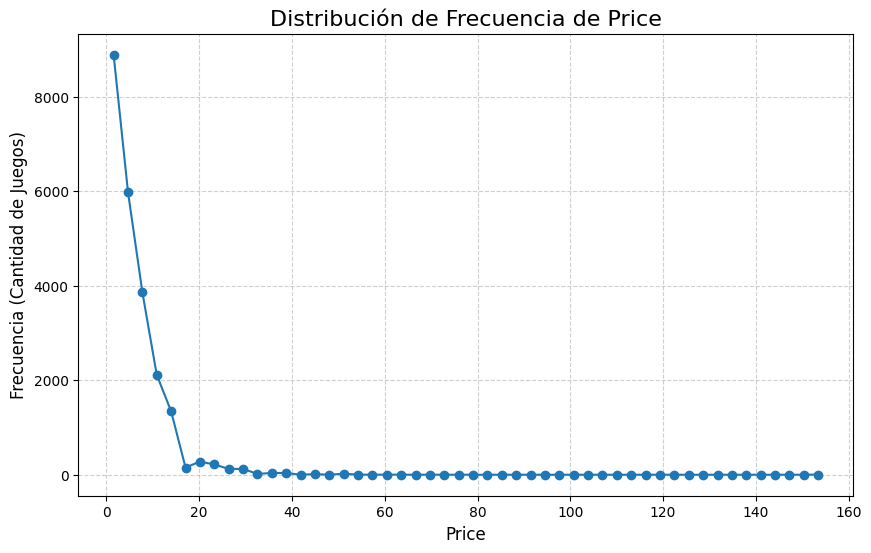

In [69]:
condition = (df_encoded["price"] == 0)
indices_to_drop = df_encoded[condition].index
df_price = df_encoded.drop(indices_to_drop)

counts, bin_edges = np.histogram(df_encoded['price'], bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de línea
plt.plot(bin_centers, counts, marker='o', linestyle='-')

plt.title('Distribución de Frecuencia de Price', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [138]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

revenues_por_genero = {}
for genero_col in columnas_generos:
    total_revenue = df_encoded[df_encoded[genero_col] == 1]['revenue'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    revenues_por_genero[nombre_limpio] = total_revenue

serie_revenues = pd.Series(revenues_por_genero)

C:\Users\alons\AppData\Local\Temp\ipykernel_25996\3104413571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


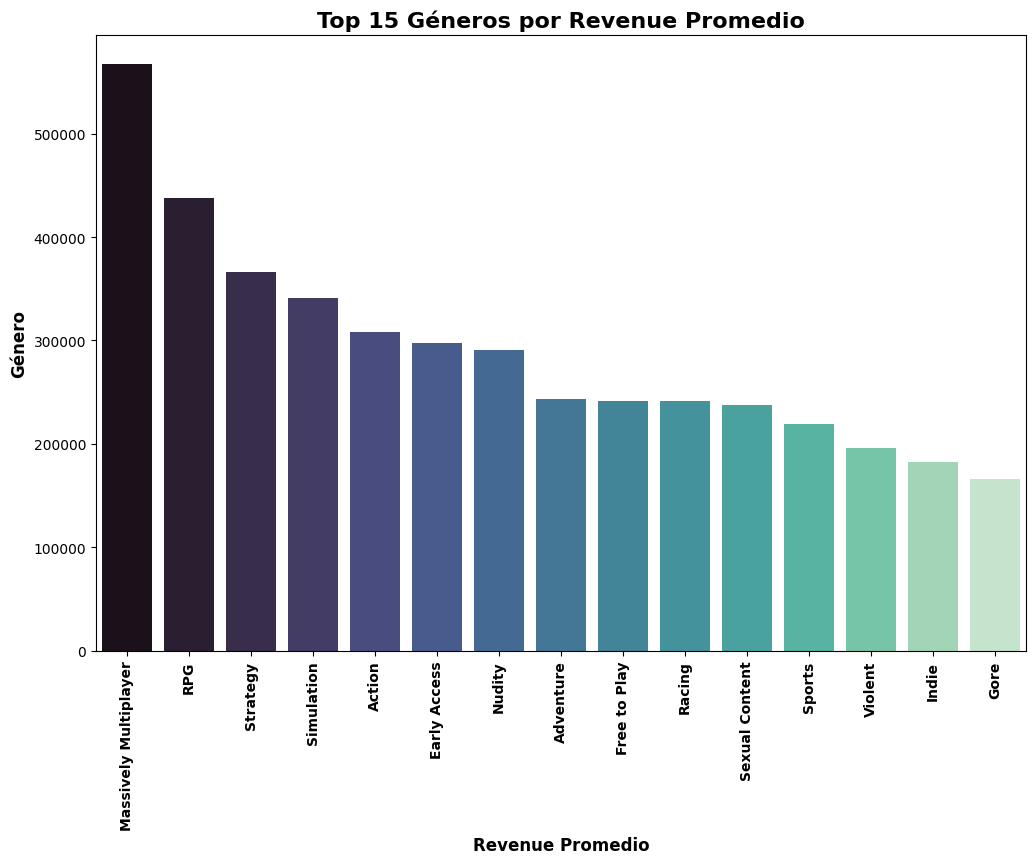

In [44]:
top_generos = serie_revenues.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))

sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.title('Top 15 Géneros por Revenue Promedio', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontweight='bold')
plt.xlabel('Revenue Promedio', fontsize=12, fontweight='bold')
plt.ylabel('Género', fontsize=12, fontweight='bold')

plt.show()

In [36]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

prices_por_genero = {}
for genero_col in columnas_generos:
    average_price = df_encoded[df_encoded[genero_col] == 1]['price'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    prices_por_genero[nombre_limpio] = average_price

serie_prices = pd.Series(prices_por_genero)

C:\Users\alons\AppData\Local\Temp\ipykernel_25996\1764708846.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


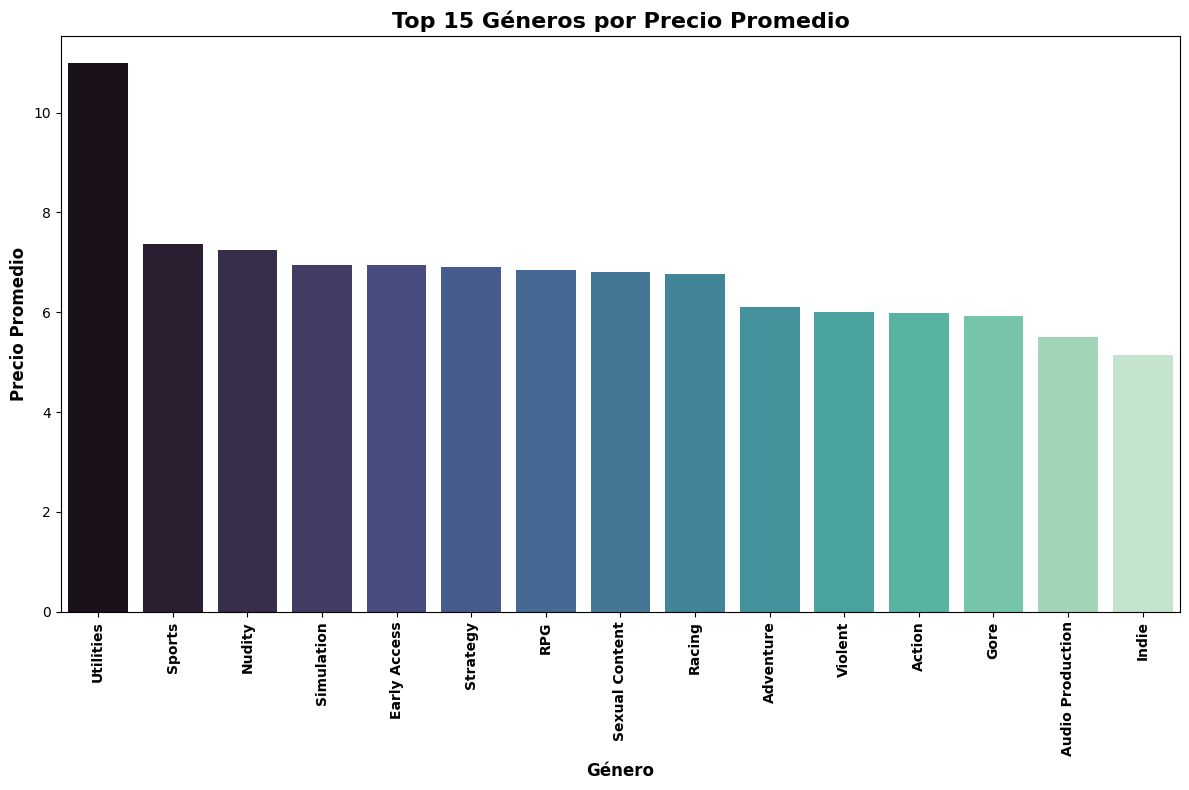

In [46]:
top_generos = serie_prices.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.xticks(rotation=90, fontweight='bold')

plt.title('Top 15 Géneros por Precio Promedio', fontsize=16,fontweight='bold')
plt.xlabel('Género', fontsize=12, fontweight='bold')
plt.ylabel('Precio Promedio', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
columnas_generos = [col for col in df_encoded.columns if col.startswith('genres_')]

prices_por_genero = {}
for genero_col in columnas_generos:
    average_score = df_encoded[df_encoded[genero_col] == 1]['reviewscore'].mean()
    nombre_limpio = genero_col.replace('genres_', '')
    prices_por_genero[nombre_limpio] = average_score

serie_prices = pd.Series(prices_por_genero)

C:\Users\alons\AppData\Local\Temp\ipykernel_25996\1906081180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')


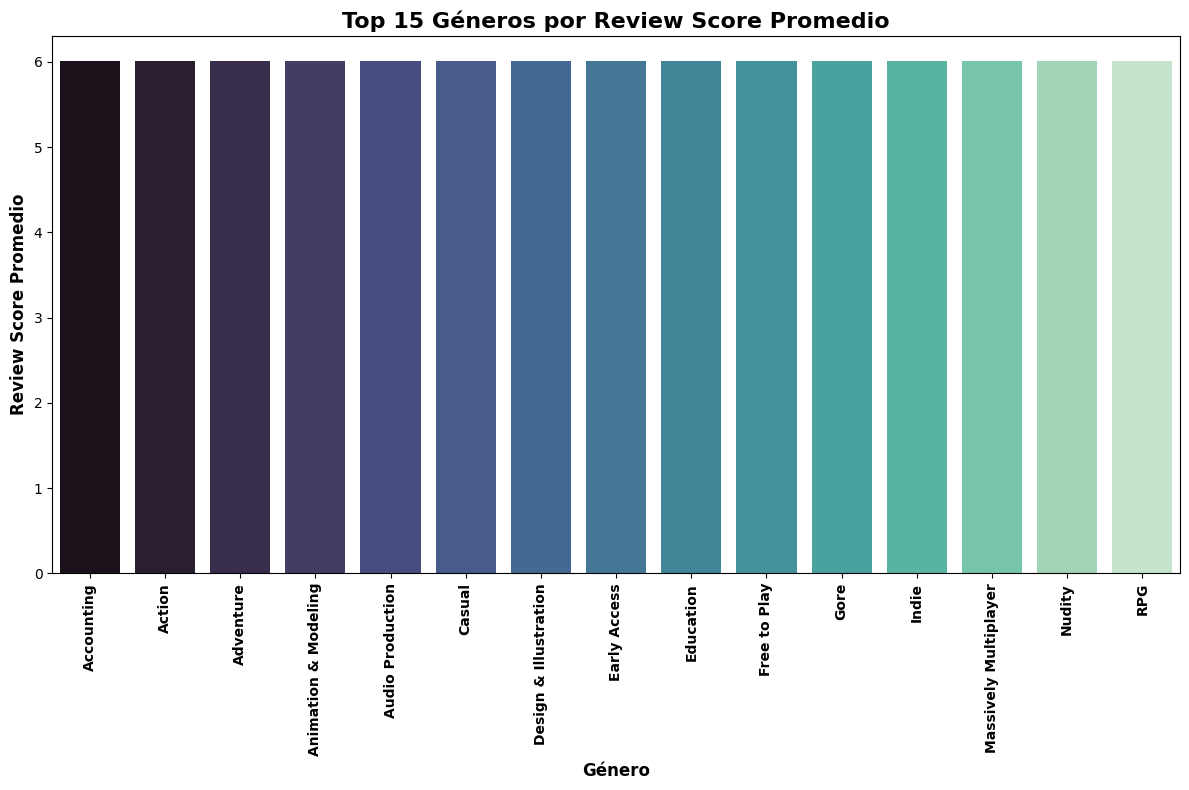

In [83]:
top_generos = serie_prices.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_generos.index, y=top_generos.values, palette='mako')

plt.xticks(rotation=90, fontweight='bold')

plt.title('Top 15 Géneros por Review Score Promedio', fontsize=16,fontweight='bold')
plt.xlabel('Género', fontsize=12, fontweight='bold')
plt.ylabel('Review Score Promedio', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()